In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader 
import matplotlib.pyplot as plt

In [2]:
# Dataset MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)  
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)  
test_loader = DataLoader(test_data, batch_size=1000)  

In [4]:
images, labels = next(iter(train_loader))

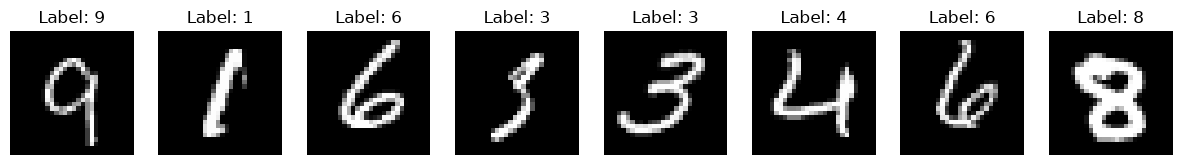

In [5]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2)) 
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')  
plt.show()

### Teacher Model (2 hidden layer)

In [6]:
class TeacherMLP(nn.Module):
    def __init__(self, hidden1=512, hidden2=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)
        )
    def forward(self, x):
        return self.net(x)

In [7]:
teacher = TeacherMLP(hidden1=512, hidden2=256)

In [8]:
print(teacher)

TeacherMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [9]:
def train_teacher(model, loader, epochs=1, lr=1e-3):

    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()

    for ep in range(epochs):
        total_loss = 0
        for x, y in loader:
            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)  
            loss.backward()
            opt.step()
            total_loss += loss.item()
        print(f"Teacher Epoch {ep+1}: Loss = {total_loss/len(loader):.4f}")

In [10]:
train_teacher(teacher, train_loader)

Teacher Epoch 1: Loss = 0.2975


In [11]:
print(teacher.state_dict())

OrderedDict({'net.1.weight': tensor([[-0.0103,  0.0288, -0.0280,  ...,  0.0031,  0.0171,  0.0359],
        [ 0.0319,  0.0087, -0.0092,  ...,  0.0201,  0.0180,  0.0464],
        [ 0.0186,  0.0144,  0.0242,  ...,  0.0220, -0.0214, -0.0188],
        ...,
        [-0.0260,  0.0268, -0.0079,  ...,  0.0023, -0.0142,  0.0235],
        [-0.0158,  0.0197,  0.0249,  ...,  0.0255,  0.0144,  0.0318],
        [ 0.0247, -0.0070,  0.0133,  ...,  0.0410, -0.0206, -0.0152]]), 'net.1.bias': tensor([ 1.9451e-02, -1.7643e-02,  2.0541e-02, -2.6762e-02, -5.1577e-03,
         3.7746e-02, -2.2806e-02, -7.6658e-03, -3.3717e-02, -1.5815e-02,
         1.1122e-02,  9.0026e-03,  2.7076e-02, -2.1556e-02,  1.1343e-02,
         3.2020e-02,  2.8671e-02, -1.7168e-02,  1.1408e-02, -1.0964e-03,
        -3.4057e-02,  9.0021e-03, -1.5210e-03, -3.9473e-02, -1.8021e-02,
        -1.4317e-03,  1.5205e-03, -4.0110e-02, -1.4363e-02,  1.6853e-02,
         2.3565e-02, -2.4304e-02,  6.6649e-03,  1.9576e-02, -2.8595e-03,
         1.

### Student Model (1 hidden layer)

In [12]:
class StudentMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 10)
        )
    def forward(self, x):
        return self.net(x)

In [13]:
student = StudentMLP(hidden=128)

In [14]:
student

StudentMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

### Distillation training

In [15]:
temperature = 2.0
alpha = 0.7
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction='batchmean')
optimizer = optim.Adam(student.parameters(), lr=1e-3)

### Process for distillation

In [16]:
# --- Training loop ---
def distill(student, teacher, loader, epochs=1):
    for ep in range(epochs):
        student.train()
        total_loss = 0
        for x, y in loader:
            # Teacher outputs (frozen — no training)
            with torch.no_grad():
                t_logits = teacher(x)
                t_probs = torch.softmax(t_logits / temperature, dim=1)

            # Student outputs
            s_logits = student(x)
            s_log_probs = torch.log_softmax(s_logits / temperature, dim=1)

            # Losses
            loss_soft = kl_loss(s_log_probs, t_probs) * (temperature**2)
            loss_hard = ce_loss(s_logits, y)
            loss = alpha * loss_soft + (1 - alpha) * loss_hard

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Student Epoch {ep+1}: Loss = {total_loss/len(loader):.4f}")

In [17]:
distill(student, teacher, train_loader)

Student Epoch 1: Loss = 0.5642


### Evaluation Function

In [18]:
def evaluate(model, loader, name="Model"):
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    return acc

In [19]:
evaluate(teacher, test_loader, "Teacher")

Teacher Accuracy: 94.09%


94.08999999999999

In [20]:
evaluate(student, test_loader, "Student")

Student Accuracy: 91.91%


91.91

### Sample prediction

In [21]:
def predict(model,x):
    model.eval()
    with torch.no_grad():
        out = model(x)
        return out.argmax(dim=1)
        

In [22]:
sample_batch, sample_labels = next(iter(test_loader))

In [23]:
preds = predict(student, sample_batch)

In [24]:
print("Sample predictions (Student):", preds[:20])

Sample predictions (Student): tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4])


### Save Student model

In [25]:
torch.save(student.state_dict(), "distilled_student.pth")
print("Student model saved as distilled_student.pth")

Student model saved as distilled_student.pth


## Different method: Training student

In [26]:
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)  
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)  
test_loader = DataLoader(test_data, batch_size=1000)  

In [27]:
images, labels = next(iter(train_loader))

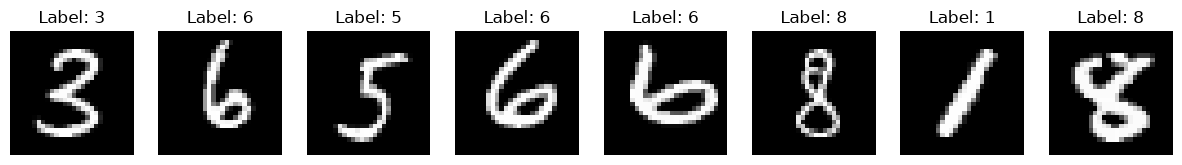

In [28]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2)) 
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')  
plt.show()

### Teacher Model (2 hidden layers)

In [29]:
class TeacherMLP(nn.Module):
    def __init__(self, hidden1=512, hidden2=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)
        )
    def forward(self, x):
        return self.net(x)

In [30]:
# Create instane
teacher = TeacherMLP(hidden1=512, hidden2=256)

In [31]:
print(teacher)

TeacherMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [32]:
# Train Teacher
def train_teacher(model, loader, epochs=1, lr=1e-3):

    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()

    for ep in range(epochs):
        total_loss = 0
        for x, y in loader:
            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)  
            loss.backward()
            opt.step()
            total_loss += loss.item()
        print(f"Teacher Epoch {ep+1}: Loss = {total_loss/len(loader):.4f}")

In [33]:
train_teacher(teacher, train_loader)

Teacher Epoch 1: Loss = 0.2996


In [35]:
print(teacher.state_dict()) # Ye updated weights dikhaega

OrderedDict({'net.1.weight': tensor([[ 0.0315, -0.0144,  0.0349,  ...,  0.0050, -0.0263, -0.0304],
        [ 0.0426,  0.0036, -0.0054,  ...,  0.0200,  0.0308,  0.0262],
        [-0.0146, -0.0257,  0.0225,  ..., -0.0096, -0.0086,  0.0330],
        ...,
        [ 0.0205, -0.0151,  0.0176,  ...,  0.0269, -0.0236,  0.0336],
        [-0.0023, -0.0205,  0.0181,  ...,  0.0109,  0.0125, -0.0058],
        [-0.0027, -0.0039, -0.0211,  ...,  0.0227, -0.0086, -0.0133]]), 'net.1.bias': tensor([-0.0272, -0.0052, -0.0234,  0.0005, -0.0002, -0.0138,  0.0207, -0.0220,
        -0.0261,  0.0007, -0.0228,  0.0076,  0.0192, -0.0056,  0.0204, -0.0064,
        -0.0006, -0.0250,  0.0080,  0.0002, -0.0162, -0.0051, -0.0315, -0.0282,
         0.0104, -0.0054,  0.0316,  0.0216,  0.0254,  0.0086,  0.0242,  0.0172,
        -0.0189,  0.0176, -0.0109,  0.0097,  0.0015, -0.0179,  0.0009, -0.0054,
         0.0136, -0.0200, -0.0170,  0.0316,  0.0220, -0.0084, -0.0320,  0.0032,
        -0.0090, -0.0291, -0.0043, -0.0334

In [36]:
# Student model
class StudentMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 10)
        )
    def forward(self, x):
        return self.net(x)

In [37]:
student = StudentMLP(hidden=128)

In [38]:
print(student)

StudentMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


### A. Pretrain student on Hard Labels (optional warmup)

In [46]:
def pretrain_student(student, loader, epochs=1, lr=1e-3):
    student.train()
    opt = optim.Adam(student.parameters(), lr=lr)
    ce_loss = nn.CrossEntropyLoss()
    for ep in range(epochs):
        for x, y in loader:
            opt.zero_grad()
            out = student(x)
            loss = ce_loss(out, y)
            loss.backward()
            opt.step()

In [47]:
pretrain_student(student, train_loader, epochs=1)

### Distillation Training

In [48]:
temperature = 2.0
alpha = 0.7
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction='batchmean')
optimizer = optim.Adam(student.parameters(), lr=1e-3)

In [49]:
# --- Training loop ---
def distill(student, teacher, loader, epochs=1):
    for ep in range(epochs):
        student.train()
        total_loss = 0
        for x, y in loader:
            # Teacher outputs (frozen — no training)
            with torch.no_grad():
                t_logits = teacher(x)
                t_probs = torch.softmax(t_logits / temperature, dim=1)

            # Student outputs
            s_logits = student(x)
            s_log_probs = torch.log_softmax(s_logits / temperature, dim=1)

            # Losses
            loss_soft = kl_loss(s_log_probs, t_probs) * (temperature**2)
            loss_hard = ce_loss(s_logits, y)
            loss = alpha * loss_soft + (1 - alpha) * loss_hard

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Student Epoch {ep+1}: Loss = {total_loss/len(loader):.4f}")

In [50]:
distill(student, teacher, train_loader)

Student Epoch 1: Loss = 0.1404


### Evaluation Function

In [51]:
def evaluate(model, loader, name="Model"):
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total * 100
    print(f"{name} Accuracy: {acc:.2f}%")
    return acc

In [52]:
evaluate(teacher, test_loader, "Teacher")

Teacher Accuracy: 95.64%


95.64

In [53]:
evaluate(student, test_loader, "Student")

Student Accuracy: 94.97%


94.97

### Sample Prediction

In [54]:
def predict(model,x):
    model.eval()
    with torch.no_grad():
        out = model(x)
        return out.argmax(dim=1)
        